In [3]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
from sklearn.metrics.cluster import adjusted_rand_score
from STAGATE import STAGATE, Train_STAGATE, utils

folder = "BZ14"
if not os.path.exists("output" + "/" + folder + "/STAGATE"):
        os.makedirs("output" + "/" + folder + "/STAGATE")

result = pd.DataFrame(columns = ["ARI", "AMI", "NMI"])

for data_index in range(10):
    data = str(data_index + 1)
    
    file_name =  "data/" + folder +".h5ad"
    adata = sc.read_h5ad(file_name)
    adata.X = adata.X.astype("float32")
    adata.obsm["spatial"] = pd.concat([adata.obs["row"], adata.obs["col"]], axis=1)


    utils.Cal_Spatial_Net(adata, rad_cutoff=450)
    adata = Train_STAGATE.train_STAGATE(adata)
    sc.pp.neighbors(adata, use_rep='STAGATE')
    sc.tl.umap(adata)
    adata = utils.mclust_P(adata, used_obsm='STAGATE', num_cluster=np.unique(adata.obs["label"]).size)

    from sklearn import metrics
    adata.obs["pred"] = adata.obs["mclust"]
    obs_df = adata.obs.dropna()
    ari = metrics.adjusted_rand_score(obs_df['pred'], obs_df['label'])
    nmi = metrics.normalized_mutual_info_score(obs_df['pred'], obs_df['label'])
    ami = metrics.adjusted_mutual_info_score(obs_df['pred'], obs_df['label'])

    values= [ari, ami, nmi]
    result.loc[data_index] = values
    obs_df["pred"].to_csv("output" + "/" + folder + "/STAGATE/" + data + ".csv")

result_file = "output/" + folder + "/STAGATE/" + "summary.csv"
result.to_csv(result_file )


------Calculating spatial graph...
The graph contains 9210 edges, 1088 cells.
8.4651 neighbors per cell on average.
Size of Input:  (1088, 166)


100%|██████████| 1000/1000 [00:03<00:00, 300.45it/s]


------Calculating spatial graph...
The graph contains 9210 edges, 1088 cells.
8.4651 neighbors per cell on average.
Size of Input:  (1088, 166)


100%|██████████| 1000/1000 [00:03<00:00, 304.29it/s]


------Calculating spatial graph...
The graph contains 9210 edges, 1088 cells.
8.4651 neighbors per cell on average.
Size of Input:  (1088, 166)


...

100%|██████████| 1000/1000 [00:03<00:00, 300.00it/s]


------Calculating spatial graph...
The graph contains 9210 edges, 1088 cells.
8.4651 neighbors per cell on average.
Size of Input:  (1088, 166)


100%|██████████| 1000/1000 [00:03<00:00, 298.60it/s]


------Calculating spatial graph...
The graph contains 9210 edges, 1088 cells.
8.4651 neighbors per cell on average.
Size of Input:  (1088, 166)


100%|██████████| 1000/1000 [00:03<00:00, 301.81it/s]


In [56]:
np.unique(adata.obs["label"]).size

5

In [39]:
%load_ext autoreload
%autoreload 2
from STAGATE import STAGATE, Train_STAGATE, utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
folder = "scenario1_7"
result = pd.DataFrame(columns = ["ARI", "AMI", "NMI"])


In [18]:
data = str(1)
file_name = folder + "/"+ "SpaGCN/data/" + data +".h5ad"
adata = sc.read_h5ad(file_name)
adata.X = adata.X.astype("float32")
adata.obsm["spatial"] = pd.concat([adata.obs["row"], adata.obs["col"]], axis=1)

------Calculating spatial graph...
The graph contains 6240 edges, 1600 cells.
3.9000 neighbors per cell on average.


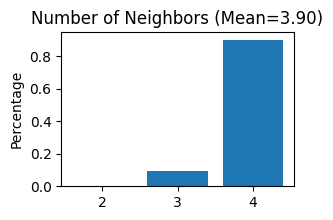

In [28]:
utils.Cal_Spatial_Net(adata, rad_cutoff=1.414)
utils.Stats_Spatial_Net(adata)

In [30]:
adata = Train_STAGATE.train_STAGATE(adata)

Size of Input:  (1600, 2000)


100%|██████████| 1000/1000 [00:03<00:00, 251.43it/s]


In [40]:
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)
adata = utils.mclust_P(adata, used_obsm='STAGATE', num_cluster=3)

In [42]:
from sklearn import metrics
adata.obs["pred"] = adata.obs["mclust"]
obs_df = adata.obs.dropna()
ari = metrics.adjusted_rand_score(obs_df['pred'], obs_df['label'])
nmi = metrics.normalized_mutual_info_score(obs_df['pred'], obs_df['label'])
ami = metrics.adjusted_mutual_info_score(obs_df['pred'], obs_df['label'])

In [45]:
ami

0.8075475466723485